# 05 — Kinship Inference (KING-robust)

Classify pairwise relationships using the KING-robust estimator, which is robust to
population structure and handles genotyping error better than IBS alone.

**Inputs**: `data/geno_dropout_filtered.csv`, `data/master_metadata.csv`
**Output**: `data/kin_pairs.csv`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import squareform

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

In [2]:
geno = pd.read_csv('../data/geno_dropout_filtered.csv', index_col=0)
meta = pd.read_csv('../data/master_metadata.csv')
print(f'Genotypes: {geno.shape[0]:,} markers x {geno.shape[1]:,} samples')
print(f'Metadata: {len(meta):,} records')

Genotypes: 11,357 markers x 836 samples
Metadata: 994 records


## KING-robust kinship estimator

KING-robust (Manichaikul et al. 2010) estimates kinship from genotype data without
assuming Hardy-Weinberg equilibrium, making it robust to population structure and
allelic dropout.

For each pair (i, j) at locus l:
- IBS0: both homozygous but for different alleles (0,2) or (2,0)
- Kinship = [N_het_ij - 2*N_IBS0] / [N_het_i + N_het_j]

Where:
- N_het_ij = number of loci where both individuals are heterozygous
- N_het_i = number of loci where individual i is heterozygous
- N_IBS0 = number of loci with opposite homozygotes

Thresholds (Manichaikul et al.):
- Parent-offspring: kinship > 0.177, IBS0 ~ 0
- Full-sibling: kinship > 0.177, IBS0 > 0 
- 2nd degree (half-sib): 0.0884 < kinship < 0.177
- 3rd degree: 0.0442 < kinship < 0.0884
- Unrelated: kinship < 0.0442

In [3]:
def king_robust_vectorized(geno_df):
    """Compute KING-robust kinship for all pairs (vectorized).
    
    Uses matrix operations to avoid per-pair loops.
    Returns kinship matrix, IBS0 matrix, and het counts.
    """
    G = geno_df.values.T.astype(float)  # samples x markers
    n_samples, n_markers = G.shape
    sample_ids = geno_df.columns.tolist()
    
    print(f'  Computing KING-robust for {n_samples} samples x {n_markers} markers...')
    
    # Replace NaN with -1 for masking
    G_masked = np.where(np.isfinite(G), G, -1)
    
    # Boolean matrices
    is_called = (G_masked >= 0)        # samples x markers
    is_het = (G_masked == 1)           # samples x markers
    is_hom_ref = (G_masked == 0)       # samples x markers
    is_hom_alt = (G_masked == 2)       # samples x markers
    
    # Per-sample het counts (for the denominator)
    n_het_per_sample = is_het.sum(axis=1)  # (n_samples,)
    
    # Pairwise counts via matrix multiplication (boolean @ boolean.T = count of co-occurrences)
    # Both called
    N_both_called = is_called.astype(np.float32) @ is_called.astype(np.float32).T
    
    # Both het: N_het_ij
    N_both_het = is_het.astype(np.float32) @ is_het.astype(np.float32).T
    
    # IBS0: (hom_ref_i AND hom_alt_j) + (hom_alt_i AND hom_ref_j)
    N_ibs0 = (is_hom_ref.astype(np.float32) @ is_hom_alt.astype(np.float32).T +
              is_hom_alt.astype(np.float32) @ is_hom_ref.astype(np.float32).T)
    
    # KING kinship = (N_both_het - 2*N_ibs0) / (N_het_i + N_het_j)
    # Denominator: N_het_i + N_het_j for each pair
    denom = n_het_per_sample[:, None] + n_het_per_sample[None, :]
    
    with np.errstate(divide='ignore', invalid='ignore'):
        kinship = (N_both_het - 2 * N_ibs0) / denom
    
    # Set diagonal to 0.5 (self-kinship)
    np.fill_diagonal(kinship, 0.5)
    
    # Set pairs with too few shared loci to NaN
    kinship[N_both_called < 100] = np.nan
    
    print(f'  Done.')
    return kinship, N_ibs0, n_het_per_sample, sample_ids

print('Computing KING-robust kinship (vectorized)...')

Computing KING-robust kinship (vectorized)...


In [4]:
%%time
kinship, ibs0_mat, n_het, sample_ids = king_robust_vectorized(geno)

  Computing KING-robust for 836 samples x 11357 markers...


  Done.
CPU times: user 1.79 s, sys: 49.7 ms, total: 1.84 s
Wall time: 267 ms


## Kinship distribution

In [5]:
# Extract upper triangle (pairwise values)
iu = np.triu_indices(len(sample_ids), k=1)
kin_vals = kinship[iu]
ibs0_vals = ibs0_mat[iu]

print(f'Pairwise kinship summary ({len(kin_vals):,} pairs):')
print(f'  Mean:   {np.nanmean(kin_vals):.4f}')
print(f'  Median: {np.nanmedian(kin_vals):.4f}')
print(f'  Max:    {np.nanmax(kin_vals):.4f}')
print(f'  Min:    {np.nanmin(kin_vals):.4f}')

# Count pairs by relationship category
n_po_or_fs = np.sum(kin_vals > 0.177)
n_2nd = np.sum((kin_vals > 0.0884) & (kin_vals <= 0.177))
n_3rd = np.sum((kin_vals > 0.0442) & (kin_vals <= 0.0884))
n_unrelated = np.sum(kin_vals <= 0.0442)

print(f'\nRelationship classification:')
print(f'  PO or FS (kinship > 0.177):    {n_po_or_fs}')
print(f'  2nd degree (0.088-0.177):       {n_2nd}')
print(f'  3rd degree (0.044-0.088):       {n_3rd}')
print(f'  Unrelated (kinship <= 0.044):   {n_unrelated:,}')

Pairwise kinship summary (349,030 pairs):
  Mean:   -0.1132
  Median: -0.0993
  Max:    0.3096
  Min:    -0.7938

Relationship classification:
  PO or FS (kinship > 0.177):    4
  2nd degree (0.088-0.177):       607
  3rd degree (0.044-0.088):       1542
  Unrelated (kinship <= 0.044):   346,877


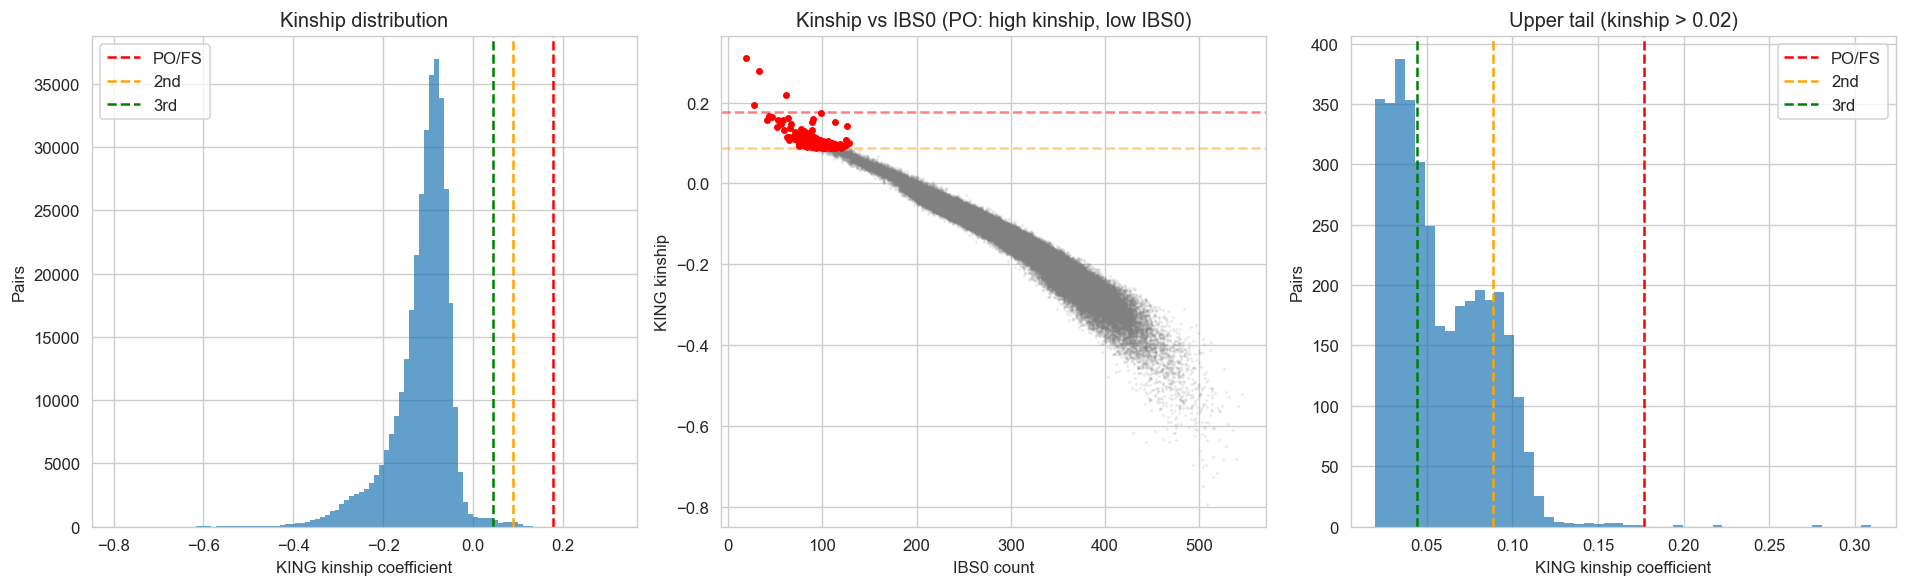

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Kinship histogram
ax = axes[0]
ax.hist(kin_vals[np.isfinite(kin_vals)], bins=100, edgecolor='none', alpha=0.7)
for thresh, label, color in [(0.177, 'PO/FS', 'red'), (0.0884, '2nd', 'orange'), (0.0442, '3rd', 'green')]:
    ax.axvline(thresh, color=color, ls='--', label=label)
ax.set_xlabel('KING kinship coefficient')
ax.set_ylabel('Pairs')
ax.set_title('Kinship distribution')
ax.legend()

# Kinship vs IBS0 (key diagnostic: PO has IBS0~0, FS has IBS0>0)
ax = axes[1]
mask = np.isfinite(kin_vals) & np.isfinite(ibs0_vals)
ax.scatter(ibs0_vals[mask], kin_vals[mask], s=1, alpha=0.1, c='grey')
# Highlight close kin
close = kin_vals > 0.0884
if close.any():
    ax.scatter(ibs0_vals[close & mask], kin_vals[close & mask], s=10, c='red', zorder=5)
ax.axhline(0.177, color='red', ls='--', alpha=0.5)
ax.axhline(0.0884, color='orange', ls='--', alpha=0.5)
ax.set_xlabel('IBS0 count')
ax.set_ylabel('KING kinship')
ax.set_title('Kinship vs IBS0 (PO: high kinship, low IBS0)')

# Zoom on upper tail
ax = axes[2]
tail = kin_vals > 0.02
if tail.any():
    ax.hist(kin_vals[tail & np.isfinite(kin_vals)], bins=50, edgecolor='none', alpha=0.7)
    for thresh, label, color in [(0.177, 'PO/FS', 'red'), (0.0884, '2nd', 'orange'), (0.0442, '3rd', 'green')]:
        ax.axvline(thresh, color=color, ls='--', label=label)
    ax.set_xlabel('KING kinship coefficient')
    ax.set_ylabel('Pairs')
    ax.set_title('Upper tail (kinship > 0.02)')
    ax.legend()

plt.tight_layout()
plt.savefig('../results/fig_kinship.png', dpi=150, bbox_inches='tight')
plt.show()

## Classify and validate kin pairs

In [7]:
def classify_pairs(kinship, ibs0_mat, sample_ids, meta, min_kinship=0.0442):
    """Extract and classify kin pairs above threshold."""
    iu = np.triu_indices(len(sample_ids), k=1)
    
    rows = []
    for idx in range(len(iu[0])):
        i, j = iu[0][idx], iu[1][idx]
        k = kinship[i, j]
        if np.isnan(k) or k < min_kinship:
            continue
        
        ibs0 = ibs0_mat[i, j]
        
        # Classify
        if k > 0.177:
            if ibs0 < 10:  # very few opposite homozygotes
                rel = 'PO'
            else:
                rel = 'FS'
        elif k > 0.0884:
            rel = '2nd'
        else:
            rel = '3rd'
        
        rows.append({
            'sample_1': sample_ids[i],
            'sample_2': sample_ids[j],
            'kinship': k,
            'ibs0': ibs0,
            'relationship': rel,
        })
    
    pairs = pd.DataFrame(rows).sort_values('kinship', ascending=False)
    
    if len(pairs) == 0:
        print('No kin pairs found above threshold.')
        return pairs
    
    # Merge metadata for validation
    meta_cols = ['sample_id', 'morph_id', 'mosquito_sex', 'plate', 'latitude', 'longitude', 
                 'date_collected', 'household_id']
    available = [c for c in meta_cols if c in meta.columns]
    meta_sub = meta[available].drop_duplicates(subset='sample_id')
    
    pairs = pairs.merge(meta_sub.rename(columns=lambda c: c + '_1' if c != 'sample_id' else 'sample_1'),
                        on='sample_1', how='left')
    pairs = pairs.merge(meta_sub.rename(columns=lambda c: c + '_2' if c != 'sample_id' else 'sample_2'),
                        on='sample_2', how='left')
    
    return pairs

kin_pairs = classify_pairs(kinship, ibs0_mat, sample_ids, meta)
print(f'Total kin pairs (kinship > 0.0442): {len(kin_pairs)}')
if len(kin_pairs) > 0:
    print(f'\nBy relationship category:')
    print(kin_pairs['relationship'].value_counts())

Total kin pairs (kinship > 0.0442): 2153

By relationship category:
relationship
3rd    1542
2nd     607
FS        4
Name: count, dtype: int64


In [8]:
# Display top pairs with metadata
display_cols = ['sample_1', 'sample_2', 'kinship', 'ibs0', 'relationship',
                'mosquito_sex_1', 'mosquito_sex_2', 'plate_1', 'plate_2',
                'date_collected_1', 'date_collected_2']
available_cols = [c for c in display_cols if c in kin_pairs.columns]

if len(kin_pairs) > 0:
    print('Top kin pairs:')
    display(kin_pairs[available_cols].head(20))
else:
    print('No kin pairs to display.')

Top kin pairs:


,sample_1,sample_2,kinship,ibs0,relationship,mosquito_sex_1,mosquito_sex_2,plate_1,plate_2,date_collected_1,date_collected_2
0,ep0000917698,ep0000915794,0.309609,19.0,FS,male,male,1.0,1.0,2025-02-25T00:00:00.000+03:00,2025-02-25T00:00:00.000+03:00
1,ep0000915423,ep0000916899,0.279328,33.0,FS,male,female,3.0,4.0,2025-03-04T00:00:00.000+03:00,2025-02-27T00:00:00.000+03:00
2,ep0000915627,ep0000919824,0.218773,62.0,FS,female,female,5.0,5.0,2025-03-04T00:00:00.000+03:00,2025-03-04T00:00:00.000+03:00
3,ep0000915794,ep0000917567,0.194039,28.0,FS,male,male,1.0,4.0,2025-02-25T00:00:00.000+03:00,2025-02-27T00:00:00.000+03:00
4,ep0000915332,ep0000914830,0.173243,99.0,2nd,female,male,5.0,5.0,2025-03-05T00:00:00.000+03:00,2025-03-05T00:00:00.000+03:00
5,ep0000917567,ep0000919824,0.166772,44.0,2nd,male,female,4.0,5.0,2025-02-27T00:00:00.000+03:00,2025-03-04T00:00:00.000+03:00
6,ep0000915630,ep0000917567,0.164094,47.0,2nd,female,male,2.0,4.0,2025-02-27T00:00:00.000+03:00,2025-02-27T00:00:00.000+03:00
7,ep0000918234,ep0000917567,0.161891,64.0,2nd,female,male,4.0,4.0,2025-02-27T00:00:00.000+03:00,2025-02-27T00:00:00.000+03:00
8,ep0000915627,ep0000915321,0.159341,90.0,2nd,female,male,5.0,5.0,2025-03-04T00:00:00.000+03:00,2025-03-05T00:00:00.000+03:00
9,ep0000917567,ep0000915142,0.157940,53.0,2nd,male,female,4.0,4.0,2025-02-27T00:00:00.000+03:00,2025-02-28T00:00:00.000+03:00


## Validate PO pairs: Mendelian error rate

In [9]:
# For identified PO pairs, compute Mendelian error rate
# (opposite homozygotes are Mendelian errors in true PO pairs)
po_pairs = kin_pairs[kin_pairs['relationship'] == 'PO']

if len(po_pairs) > 0:
    print(f'Validating {len(po_pairs)} PO pairs:')
    for _, pair in po_pairs.iterrows():
        g1 = geno[pair['sample_1']]
        g2 = geno[pair['sample_2']]
        both = g1.notna() & g2.notna()
        n_shared = both.sum()
        
        # Mendelian errors: opposite homozygotes
        me = ((g1[both] == 0) & (g2[both] == 2)) | ((g1[both] == 2) & (g2[both] == 0))
        me_rate = me.sum() / n_shared
        
        # IBS distribution
        ibs0 = me.sum()
        ibs1 = ((g1[both] != g2[both]) & ~me).sum()
        ibs2 = (g1[both] == g2[both]).sum()
        
        print(f'\n  {pair["sample_1"]} x {pair["sample_2"]}:')
        print(f'    Kinship: {pair["kinship"]:.4f}')
        print(f'    Shared loci: {n_shared:,}')
        print(f'    Mendelian errors: {ibs0} ({me_rate:.4f})')
        print(f'    IBS: 0={ibs0}, 1={ibs1}, 2={ibs2}')
else:
    print('No PO pairs identified. Checking FS pairs for Mendelian patterns...')
    fs_pairs = kin_pairs[kin_pairs['relationship'] == 'FS']
    if len(fs_pairs) > 0:
        for _, pair in fs_pairs.head(5).iterrows():
            g1 = geno[pair['sample_1']]
            g2 = geno[pair['sample_2']]
            both = g1.notna() & g2.notna()
            n_shared = both.sum()
            me = ((g1[both] == 0) & (g2[both] == 2)) | ((g1[both] == 2) & (g2[both] == 0))
            print(f'  {pair["sample_1"]} x {pair["sample_2"]}: kinship={pair["kinship"]:.4f}, IBS0={me.sum()}, shared={n_shared}')

No PO pairs identified. Checking FS pairs for Mendelian patterns...
  ep0000917698 x ep0000915794: kinship=0.3096, IBS0=19, shared=11238
  ep0000915423 x ep0000916899: kinship=0.2793, IBS0=33, shared=11202
  ep0000915627 x ep0000919824: kinship=0.2188, IBS0=62, shared=11276
  ep0000915794 x ep0000917567: kinship=0.1940, IBS0=28, shared=11284


## Resolve duplicate barcodes

In [10]:
# Check if any duplicate barcodes appear in kin pairs
dup_barcodes = ['ep0000915423', 'ep0000919001', 'ep0000909970', 'ep0000915142', 'ep0000916071', 'ep0000919729']

kin_with_dups = kin_pairs[
    kin_pairs['sample_1'].isin(dup_barcodes) | kin_pairs['sample_2'].isin(dup_barcodes)
]

if len(kin_with_dups) > 0:
    print(f'Kin pairs involving duplicate barcodes: {len(kin_with_dups)}')
    print(kin_with_dups[available_cols])
else:
    print('No kin pairs involve duplicate barcodes — duplicates do not bias kinship results.')

Kin pairs involving duplicate barcodes: 186
          sample_1      sample_2   kinship   ibs0 relationship mosquito_sex_1  \
1     ep0000915423  ep0000916899  0.279328   33.0           FS           male   
9     ep0000917567  ep0000915142  0.157940   53.0          2nd           male   
14    ep0000915794  ep0000915142  0.147112   67.0          2nd           male   
22    ep0000915142  ep0000919824  0.129946   81.0          2nd         female   
32    ep0000915142  ep0000915627  0.120624   88.0          2nd         female   
...            ...           ...       ...    ...          ...            ...   
2126  ep0000915142  ep0000924854  0.044838  158.0          3rd         female   
2131  ep0000915142  ep0000844501  0.044680  143.0          3rd         female   
2133  ep0000915142  ep0000842199  0.044611  166.0          3rd         female   
2141  ep0000915142  ep0000915595  0.044464  169.0          3rd         female   
2146  ep0000915142  ep0000842946  0.044405  151.0          3rd   

## Estimate genotyping error from PO pairs

In [11]:
# If we have PO pairs, Mendelian error rate gives a direct estimate of per-locus error
po_pairs = kin_pairs[kin_pairs['relationship'].isin(['PO', 'FS'])]

if len(po_pairs) > 0:
    all_me_rates = []
    for _, pair in po_pairs.iterrows():
        g1 = geno[pair['sample_1']]
        g2 = geno[pair['sample_2']]
        both = g1.notna() & g2.notna()
        me = ((g1[both] == 0) & (g2[both] == 2)) | ((g1[both] == 2) & (g2[both] == 0))
        all_me_rates.append(me.sum() / both.sum())
    
    mean_error = np.mean(all_me_rates)
    print(f'Estimated genotyping error rate (from {len(po_pairs)} close-kin pairs):')
    print(f'  Mean Mendelian error rate: {mean_error:.4f}')
    print(f'  This is an upper bound — includes true recombination events.')
else:
    print('No close-kin pairs available for error estimation.')

Estimated genotyping error rate (from 4 close-kin pairs):
  Mean Mendelian error rate: 0.0032
  This is an upper bound — includes true recombination events.


## Save classified kin pairs

In [12]:
kin_pairs.to_csv('../data/kin_pairs.csv', index=False)
print(f'Saved: data/kin_pairs.csv ({len(kin_pairs)} pairs)')

# Summary
print(f'\n=== Kinship Summary ===')
print(f'Total samples: {len(sample_ids)}')
print(f'Total markers: {geno.shape[0]:,}')
print(f'Kin pairs found: {len(kin_pairs)}')
for rel in ['PO', 'FS', '2nd', '3rd']:
    n = (kin_pairs['relationship'] == rel).sum()
    if n > 0:
        print(f'  {rel}: {n}')

Saved: data/kin_pairs.csv (2153 pairs)

=== Kinship Summary ===
Total samples: 836
Total markers: 11,357
Kin pairs found: 2153
  FS: 4
  2nd: 607
  3rd: 1542
